In [46]:
import torch
import shutil
import os
import time


from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter13_14 import muscl_reconstruction, transmissive_bc
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter16 import strang_update
from CFD.Riemann_Solvers_and_Numerical_Methods_for_Fluid_Dynamics_by_TORO.chapter10 import HLLC_Riemann_Solver
from CFD import Simulator
from CFD import create_explosion_initial_condition

from CFD import LinesOnVolume, create_random_sphere_points, create_uniform_sphere_points

from CFD import generate_multiband_smooth_noise_fft

from JupyterVisualizer import visualize_voxel, ImageVisualizer, visualize_point_cloud

from util import create_boundary_band_solid_mask, create_sphere_solid_mask

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

folder = "/TMP_MOUNT/cells"
folder_full = "/TMP_MOUNT/cells_full"

shutil.rmtree(folder, ignore_errors=True)
os.makedirs(folder, exist_ok=True)


Using device: cuda
CUDA device: NVIDIA GeForce RTX 5080


In [47]:
#physical quantities--------------------------------------------

X_DOMAIN = [0, 2] # 1 m
Y_DOMAIN = [0, 1] # 1 m
Z_DOMAIN = [0, 1] # 1 m
T_DOMAIN = [0, 5]
EXPLOSION_T = 0.15

GAMMA = 1.4

#simulation parameters--------------------------------------------
#z, y, x
#for 2dim simulateion set z_domain to 1
DIMENSION = 3

if(DIMENSION == 3):
    RESOLUTION = 60, 60, 120
else:
    RESOLUTION = 1, 2000, 1000


DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.6
TOL = 1e-6

#explosion parameters--------------------------------------------

# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

# Initial Conditions
rho_inner_phy = 3 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.01
boundary_band_radius = 0.05

num_polylines = 100

#num_points = 200
num_points = 100

In [48]:

'''
CELL = create_explosion_initial_condition(
    nx = RESOLUTION[2],
    ny = RESOLUTION[1],
    nz = RESOLUTION[0],
    x_domain = X_DOMAIN,
    y_domain = Y_DOMAIN,
    z_domain = Z_DOMAIN,
    rho_inner = rho_inner,
    p_inner = p_inner,
    rho_outer = rho_outer,
    p_outer = p_outer,
    sigma = sigma,
    noise = 0,
    r_k0_list   = [],
    weight_list = [],
    device = device
)

source = CELL.clone()

'''

'\nCELL = create_explosion_initial_condition(\n    nx = RESOLUTION[2],\n    ny = RESOLUTION[1],\n    nz = RESOLUTION[0],\n    x_domain = X_DOMAIN,\n    y_domain = Y_DOMAIN,\n    z_domain = Z_DOMAIN,\n    rho_inner = rho_inner,\n    p_inner = p_inner,\n    rho_outer = rho_outer,\n    p_outer = p_outer,\n    sigma = sigma,\n    noise = 0,\n    r_k0_list   = [],\n    weight_list = [],\n    device = device\n)\n\nsource = CELL.clone()\n\n'

In [49]:
u1 = 0.8
u2 = 0.2
A  = 0.01

nx = RESOLUTION[2]
ny = RESOLUTION[1]
nz = RESOLUTION[0]

CELL = torch.zeros((nz, ny, nx, 5), device=device)
CELL[..., 0] = rho_outer
CELL[..., 4] = p_outer

y = torch.arange(ny, device=device)[None, :, None].expand(nz, ny, nx)

# shear layer center
y0 = RESOLUTION[1] / 2
delta = 1.0
sigma = 3.0

Uc = 0.5 * (u1 + u2)
dU = u1 - u2

# streamwise velocity
CELL[..., 1] = Uc + 0.5 * dU * torch.tanh((y0 - y) / delta)

# envelope localized near interface
envelope = torch.exp(-((y - y0) / sigma) ** 2)

# perturbation noise
r_k0_list   = [0.06, 0.12, 0.22]
weight_list = [1.00, 0.45, 0.18]

noise_v = generate_multiband_smooth_noise_fft(
    RESOLUTION, r_k0_list, weight_list, device=device
)
noise_w = generate_multiband_smooth_noise_fft(
    RESOLUTION, r_k0_list, weight_list, device=device
)

CELL[..., 2] = A * envelope * noise_v
CELL[..., 3] = A * envelope * noise_w

source = CELL.clone()

In [50]:
'''
boundary_band = create_boundary_band_solid_mask(
    RESOLUTION, 0.1, 0.4, boundary_band_radius, DX, DY, DZ
)

lines = create_random_sphere_points(
    boundary_band_radius,
    num_polylines,
    num_points,
    X_DOMAIN,
    Y_DOMAIN,
    Z_DOMAIN,
    device
)

# lines: (num_polylines, num_points, 4)
# 첫 번째 점의 xyz만 사용
first_points = lines[:, 0, :3]   # (num_polylines, 3)

# domain에서 voxel index로 변환
# 가정:
# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)
x_min, _ = X_DOMAIN
y_min, _ = Y_DOMAIN
z_min, _ = Z_DOMAIN

ix = ((first_points[:, 0] - x_min) / DX).long()
iy = ((first_points[:, 1] - y_min) / DY).long()
iz = ((first_points[:, 2] - z_min) / DZ).long()

# index 범위 보호
ix = torch.clamp(ix, 0, RESOLUTION[0] - 1)
iy = torch.clamp(iy, 0, RESOLUTION[1] - 1)
iz = torch.clamp(iz, 0, RESOLUTION[2] - 1)

# boundary_band 위에 있는 polyline 제거
# boundary_band가 bool tensor든 0/1 tensor든 동작 가능
keep_mask = boundary_band[iz, iy, ix] == 0

lines = lines[keep_mask]


lines = LinesOnVolume(2000, 2000, lines)

sphere = create_sphere_solid_mask(RESOLUTION)

radom_solid_cell = torch.rand(RESOLUTION, device=device) < 0.005

solid_cell = boundary_band | sphere | radom_solid_cell

point_cloud = lines.lines[:, 0, :3].clone()

point_cloud[:, 0] *= RESOLUTION[0]
point_cloud[:, 1] *= RESOLUTION[1]
point_cloud[:, 2] *= RESOLUTION[2]

#visualize_voxel(boundary_band | radom_solid_cell, point_cloud = point_cloud, save_path="./boundary_band.mp4")

#visualize_point_cloud(point_cloud, save_path = "./point_cloud.mp4")

del boundary_band, sphere
'''

'\nboundary_band = create_boundary_band_solid_mask(\n    RESOLUTION, 0.1, 0.4, boundary_band_radius, DX, DY, DZ\n)\n\nlines = create_random_sphere_points(\n    boundary_band_radius,\n    num_polylines,\n    num_points,\n    X_DOMAIN,\n    Y_DOMAIN,\n    Z_DOMAIN,\n    device\n)\n\n# lines: (num_polylines, num_points, 4)\n# 첫 번째 점의 xyz만 사용\nfirst_points = lines[:, 0, :3]   # (num_polylines, 3)\n\n# domain에서 voxel index로 변환\n# 가정:\n# X_DOMAIN = (x_min, x_max), Y_DOMAIN = (y_min, y_max), Z_DOMAIN = (z_min, z_max)\nx_min, _ = X_DOMAIN\ny_min, _ = Y_DOMAIN\nz_min, _ = Z_DOMAIN\n\nix = ((first_points[:, 0] - x_min) / DX).long()\niy = ((first_points[:, 1] - y_min) / DY).long()\niz = ((first_points[:, 2] - z_min) / DZ).long()\n\n# index 범위 보호\nix = torch.clamp(ix, 0, RESOLUTION[0] - 1)\niy = torch.clamp(iy, 0, RESOLUTION[1] - 1)\niz = torch.clamp(iz, 0, RESOLUTION[2] - 1)\n\n# boundary_band 위에 있는 polyline 제거\n# boundary_band가 bool tensor든 0/1 tensor든 동작 가능\nkeep_mask = boundary_band[iz, iy, ix

In [51]:
# 1. 각 좌표 생성 (Shape: [num_polylines])
y_middle = (Y_DOMAIN[0] + Y_DOMAIN[1]) / 2
gap = 0.1

y_min = y_middle - gap
y_max = y_middle + gap 

x_pos = torch.rand(num_polylines, device=device) * X_DOMAIN[1]
y_pos = torch.rand(num_polylines, device=device) * (y_max - y_min) + y_min
z_pos = torch.rand(num_polylines, device=device)
w_pos = torch.ones(num_polylines, device=device)

# 2. 마지막 차원으로 쌓기 (Shape: [num_polylines, 4])
# stack의 dim=-1을 사용하면 (4, N)이 아닌 (N, 4)로 바로 합쳐집니다.
pos = torch.stack([x_pos, y_pos, z_pos, w_pos], dim=-1)

# 3. 차원을 하나 추가하고 num_points만큼 반복 (Shape: [num_polylines, num_points, 4])
# unsqueeze(1)을 통해 [N, 1, 4]를 만든 뒤, 중간 차원을 num_points배 늘립니다.
lines = pos.unsqueeze(1).repeat(1, num_points, 1)
#lines[:, -1, 0] = X_DOMAIN[1]

lines = LinesOnVolume(2000, 2000, lines, max_length = 1)

In [52]:
sim = Simulator(
    CELL,
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=HLLC_Riemann_Solver,
    reconstruction_method=muscl_reconstruction,
    boundary_function=transmissive_bc,
    update_method=strang_update,
    solid_cell = None,
    dimension=DIMENSION,
    visualizers=[lines]
)

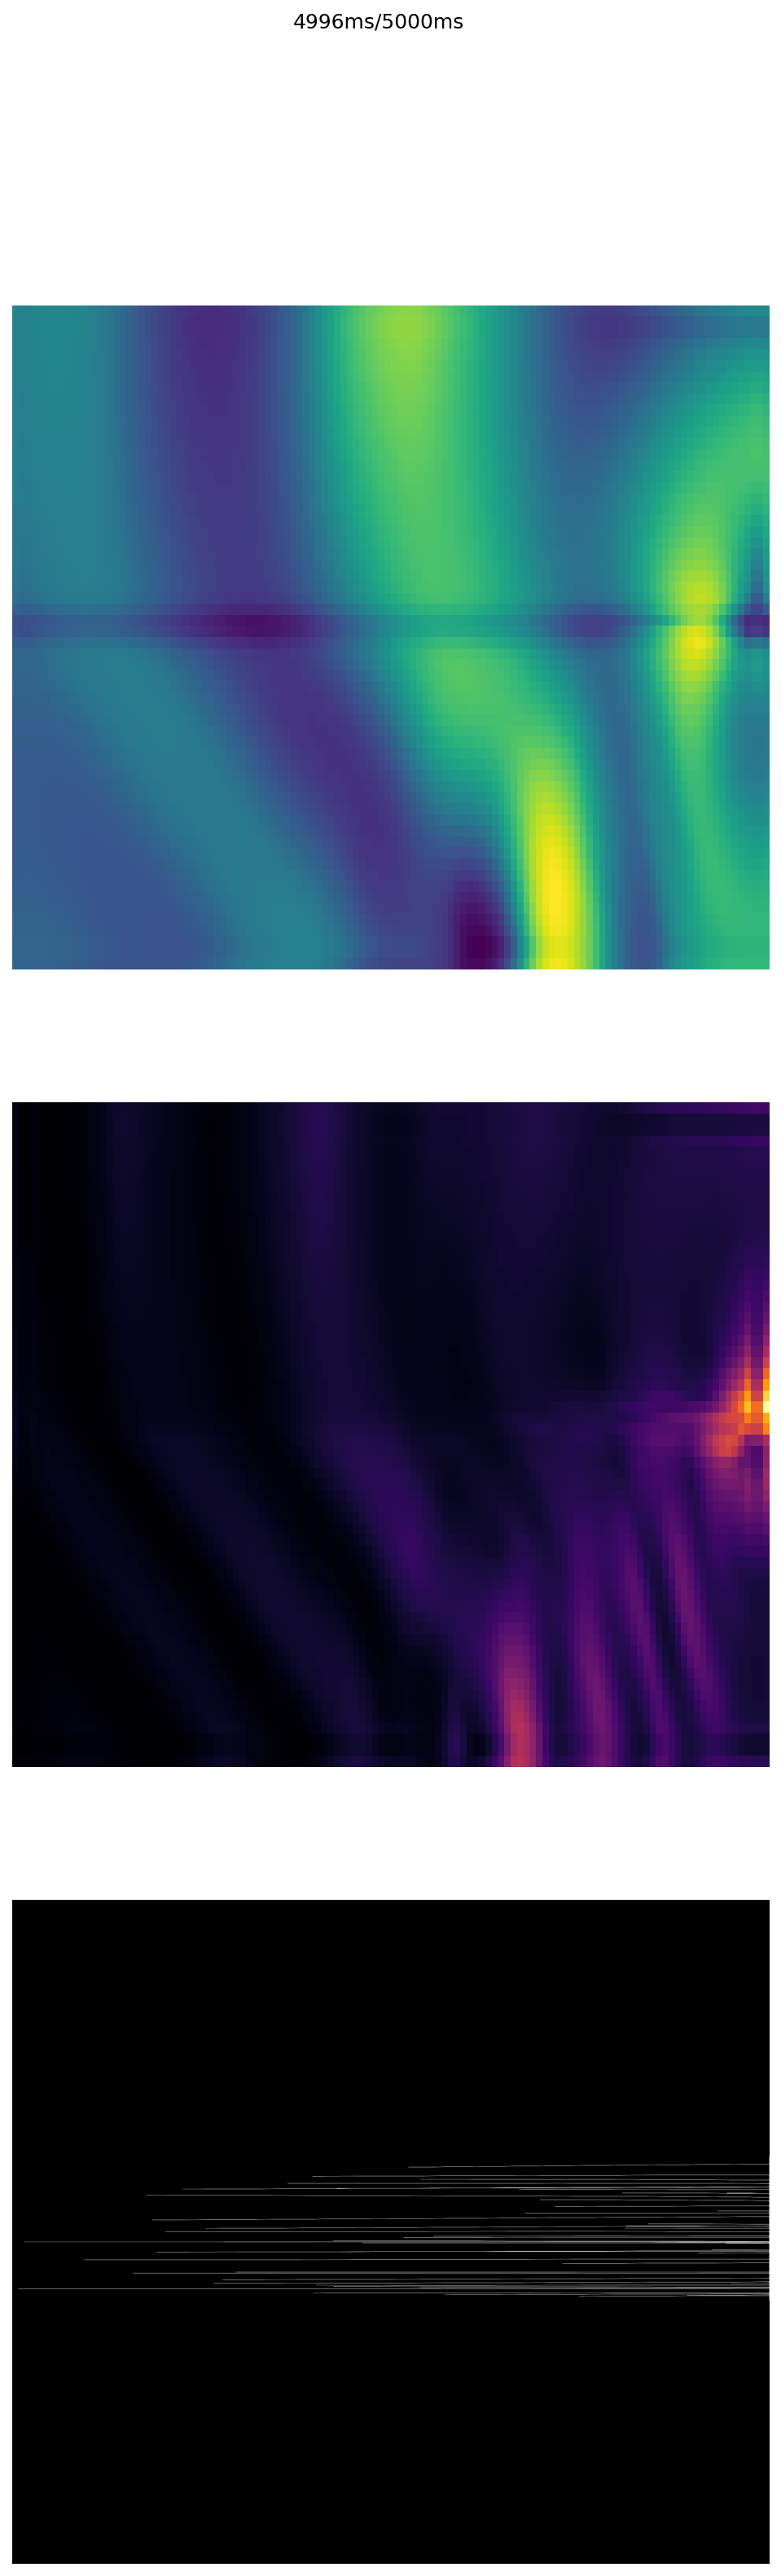

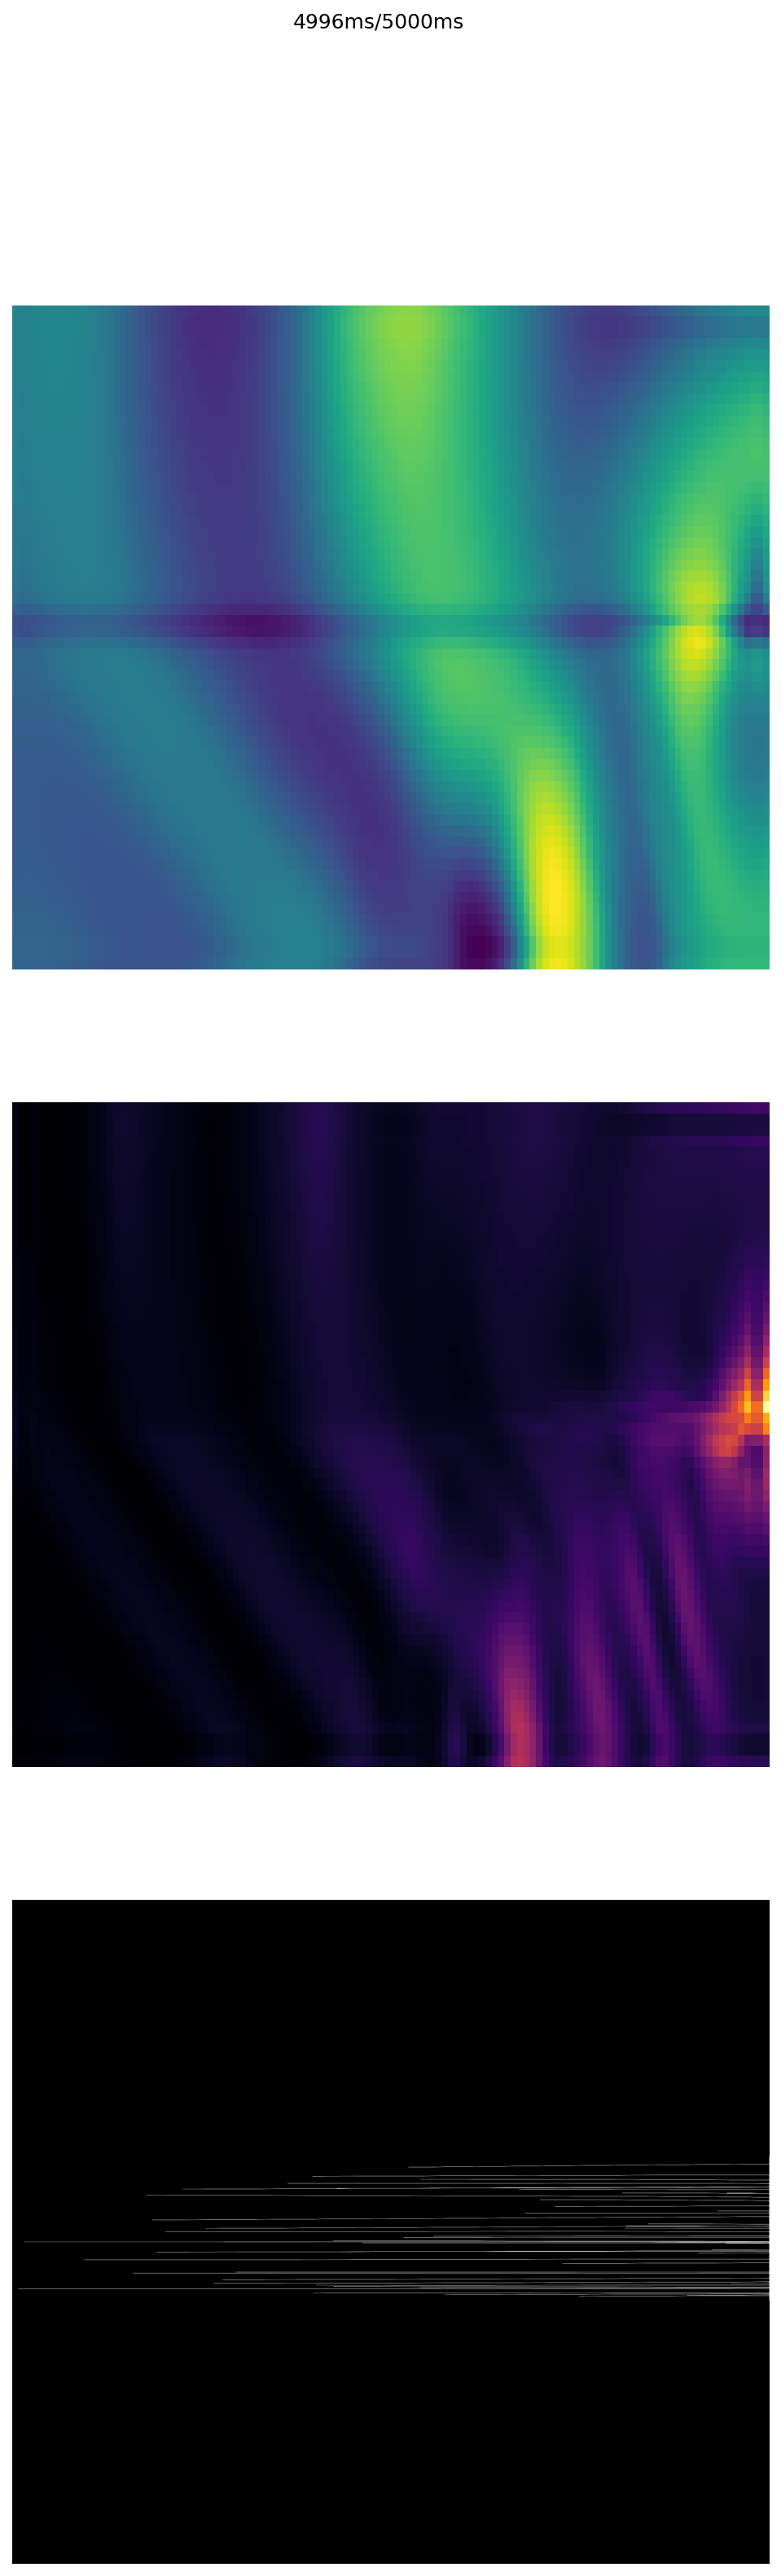

In [53]:
t = T_DOMAIN[0]
counter = 0

dt_record = []

IV = ImageVisualizer((sim.get_images_num(), 1), record = True, save_path="./run", figsize=(8, 8 * sim.get_images_num()), cmaps = ["viridis", "inferno", None])
IV.update(sim.get_images(), t)

while t < T_DOMAIN[1]:
    counter += 1
    dt = sim.update()
    t += dt
    dt_record.append(dt)

    if(t < EXPLOSION_T):
        #sim.cell[..., 0] = torch.max(sim.cell[..., 0], source[..., 0])
        #sim.cell[..., 4] = torch.max(sim.cell[..., 4], source[..., 4])
        CELL[:,:,:3,1] = source[:,:,:3,1]
        
    if(counter % 3 == 0):
        #torch.save(sim.cell.half(), f"{folder}/{t}.pt")
        IV.set_title(f"{round(t.item() * 1000)}ms/{T_DOMAIN[1] * 1000}ms")
        IV.update(sim.get_images(), t.item())

    '''
    if(counter % 60 == 0):
        shutil.rmtree(folder_full, ignore_errors=True)
        os.makedirs(folder_full, exist_ok=True)
        torch.save(sim.cell, f"{folder_full}/{t}.pt")
    '''

In [54]:
IV.close(PB_speed=1)

ffmpeg version 4.4.2 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 12.3.0 (conda-forge gcc 12.3.0-2)
  configuration: --prefix=/home/ty/anaconda3/envs/torch --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1697113881276/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --disable-openssl --enable-avresample --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libfontconfig --enable-libopenh264 --enable-gnutls --enable-libmp3lame --enable-libvpx --enable-pthreads --enable-vaapi --enable-gpl --enable-libx264 --enable-libx265 --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disa

frame=  128 fps=0.0 q=-1.0 Lsize=      23kB time=00:00:05.00 bitrate=  36.9kbits/s dup=0 drop=201 speed=50.8x    
video:20kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 10.782617%
[libx264 @ 0x5fe325551400] frame I:2     Avg QP:17.72  size:   150
[libx264 @ 0x5fe325551400] frame P:65    Avg QP:23.65  size:   207
[libx264 @ 0x5fe325551400] frame B:61    Avg QP:23.89  size:   104
[libx264 @ 0x5fe325551400] consecutive B-frames: 25.0% 31.2%  9.4% 34.4%
[libx264 @ 0x5fe325551400] mb I  I16..4: 67.2% 32.8%  0.0%
[libx264 @ 0x5fe325551400] mb P  I16..4:  2.5%  6.8%  1.2%  P16..4: 37.7% 15.9%  6.0%  0.0%  0.0%    skip:30.0%
[libx264 @ 0x5fe325551400] mb B  I16..4:  0.2%  1.6%  0.3%  B16..8: 26.0%  6.9%  1.6%  direct: 4.7%  skip:58.7%  L0:25.7% L1:51.1% BI:23.3%
[libx264 @ 0x5fe325551400] 8x8 transform intra:60.4% inter:80.2%
[libx264 @ 0x5fe325551400] coded y,uvDC,uvAC intra: 47.3% 72.1% 56.3% inter: 14.3% 27.3% 9.8%
[libx264 @ 0x5fe325551400] i16 v,h,dc,p: 41